# Notebook 13: Attack Taxonomy with Feature Signatures

**Purpose:** Map attack categories to their characteristic SAE feature patterns, demonstrating that the SAE has learned *structured* representations of different injection strategies — not just a binary classifier.

**Key visualizations:**
- Heatmap: rows = top features, columns = attack categories
- Similarity matrix between categories
- Category-specific features (one-vs-rest)
- Attack type classification from feature patterns

**Expected findings:**
- `override` and `extraction` share features
- `mimicry` looks like normal prompts (explains high evasion rate)
- `encoded` shares features with `override` (SAE detects meaning, not keywords)

**Prerequisites:** Run notebooks 10-12 first.

**Runtime:** Colab GPU (T4), ~10 minutes.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -r /content/drive/MyDrive/iris/requirements.txt -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/iris')

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

from src.utils.helpers import set_seed, get_device
set_seed(42)
device = get_device()

DRIVE_ROOT = Path('/content/drive/MyDrive/iris')

Using GPU: NVIDIA L4


## Step 0: Load Data and Features

In [ ]:
from src.data.dataset import IrisDataset
from src.sae.architecture import SparseAutoencoder
from src.utils.helpers import load_checkpoint

# MUST use balanced dataset — feature_matrix.npy was computed from it.
# Using expanded would create a label/feature mismatch (same row count
# but different examples, so labels wouldn't correspond to feature rows).
ds_path = DRIVE_ROOT / 'data' / 'processed' / 'iris_dataset_balanced.json'
dataset = IrisDataset.load(ds_path)
labels = np.array(dataset.labels)
categories = np.array([ex.get('category', 'normal' if ex.get('label', 0) == 0 else 'injection') for ex in dataset.examples])

# Load pre-computed features and sensitivity
feature_matrix = np.load(str(DRIVE_ROOT / 'checkpoints' / 'feature_matrix.npy'))
sensitivity = np.load(str(DRIVE_ROOT / 'checkpoints' / 'sensitivity_scores.npy'))
assert feature_matrix.shape[0] == len(labels), (
    f'feature_matrix has {feature_matrix.shape[0]} rows but dataset has {len(labels)} examples — '
    f'they were probably computed from different datasets'
)

# Category breakdown
unique_cats, cat_counts = np.unique(categories, return_counts=True)
print('Category distribution:')
for cat, count in zip(unique_cats, cat_counts):
    print(f'  {cat}: {count}')
print(f'Total: {len(dataset)} examples')

## Step 1: Compute Category Fingerprints

The 'fingerprint' of a category is its mean activation pattern across the top-50 most sensitive features.

In [4]:
from src.analysis.taxonomy import (
    compute_category_fingerprints,
    compute_category_similarity,
    identify_category_specific_features,
    classify_attack_type,
    build_taxonomy_heatmap_data,
)

fingerprints = compute_category_fingerprints(
    feature_matrix, labels, categories.tolist(),
    top_k=50, sensitivity_scores=sensitivity,
)

print('Category fingerprints computed:')
for cat, fp in fingerprints.items():
    nonzero = (fp > 0.01).sum()
    mean_act = fp.mean()
    print(f'  {cat}: {nonzero} active features (of top-50), mean activation = {mean_act:.4f}')

Category fingerprints computed:
  brainstorming: 50 active features (of top-50), mean activation = 5.9298
  classification: 50 active features (of top-50), mean activation = 6.0145
  closed_qa: 50 active features (of top-50), mean activation = 5.9752
  creative_writing: 50 active features (of top-50), mean activation = 5.4436
  extraction: 50 active features (of top-50), mean activation = 5.6908
  general_qa: 50 active features (of top-50), mean activation = 5.9764
  indirect: 50 active features (of top-50), mean activation = 5.7320
  information_extraction: 50 active features (of top-50), mean activation = 5.2582
  instruction: 50 active features (of top-50), mean activation = 5.8473
  mixed: 50 active features (of top-50), mean activation = 6.0163
  open_qa: 50 active features (of top-50), mean activation = 6.2932
  override: 50 active features (of top-50), mean activation = 5.6902
  roleplay: 50 active features (of top-50), mean activation = 5.9164
  summarization: 50 active feature

## Step 2: Category Similarity Matrix

Pairwise cosine similarity between fingerprints reveals which attack types are most similar in feature space.

In [5]:
sim_matrix, cat_names = compute_category_similarity(fingerprints)

# Print similarity matrix
print('Cosine Similarity Matrix:')
print(f'{"":>15}', end='')
for name in cat_names:
    print(f'{name[:10]:>12}', end='')
print()
for i, name_i in enumerate(cat_names):
    print(f'{name_i[:15]:>15}', end='')
    for j in range(len(cat_names)):
        print(f'{sim_matrix[i, j]:>12.3f}', end='')
    print()

Cosine Similarity Matrix:
                 brainstorm  classifica   closed_qa  creative_w  extraction  general_qa    indirect  informatio  instructio       mixed     open_qa    override    roleplay  summarizat
  brainstorming       1.000       0.985       0.991       0.962       0.987       0.985       0.991       0.983       0.990       0.991       0.985       0.987       0.988       0.981
 classification       0.985       1.000       0.994       0.980       0.993       0.992       0.994       0.988       0.995       0.995       0.991       0.993       0.995       0.989
      closed_qa       0.991       0.994       1.000       0.978       0.994       0.994       0.994       0.987       0.997       0.996       0.994       0.994       0.994       0.986
creative_writin       0.962       0.980       0.978       1.000       0.980       0.982       0.980       0.979       0.982       0.977       0.977       0.981       0.982       0.969
     extraction       0.987       0.993       0.994   

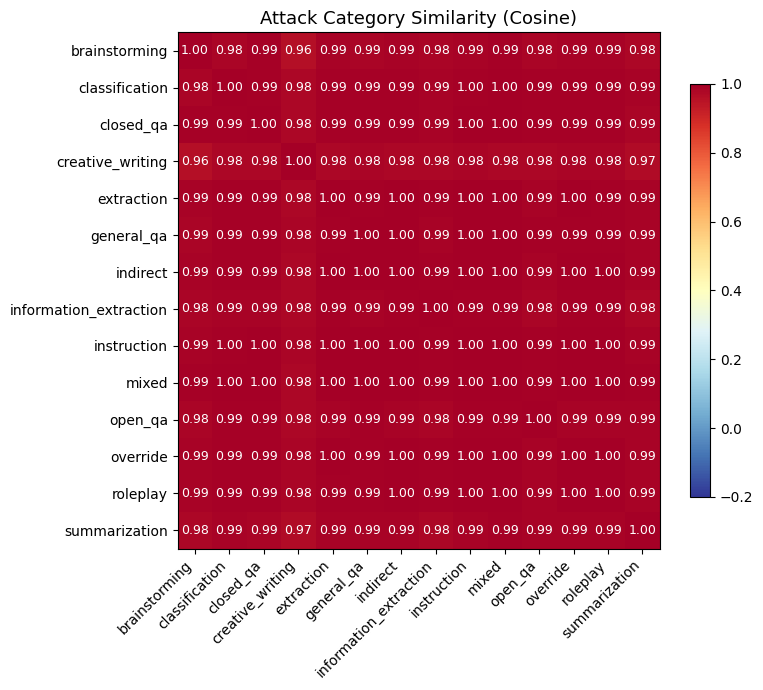

Saved to /content/drive/MyDrive/iris/results/figures/taxonomy_similarity.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(sim_matrix, cmap='RdYlBu_r', vmin=-0.2, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(cat_names)))
ax.set_yticks(range(len(cat_names)))
ax.set_xticklabels(cat_names, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(cat_names, fontsize=10)
ax.set_title('Attack Category Similarity (Cosine)', fontsize=13)

# Add text annotations
for i in range(len(cat_names)):
    for j in range(len(cat_names)):
        color = 'white' if sim_matrix[i, j] > 0.7 or sim_matrix[i, j] < 0.0 else 'black'
        ax.text(j, i, f'{sim_matrix[i, j]:.2f}', ha='center', va='center',
                fontsize=9, color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
save_path = DRIVE_ROOT / 'results' / 'figures' / 'taxonomy_similarity.png'
fig.savefig(str(save_path), dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved to {save_path}')

## Step 3: Feature Activation Heatmap

The core taxonomy visualization: which features fire for which attack categories.

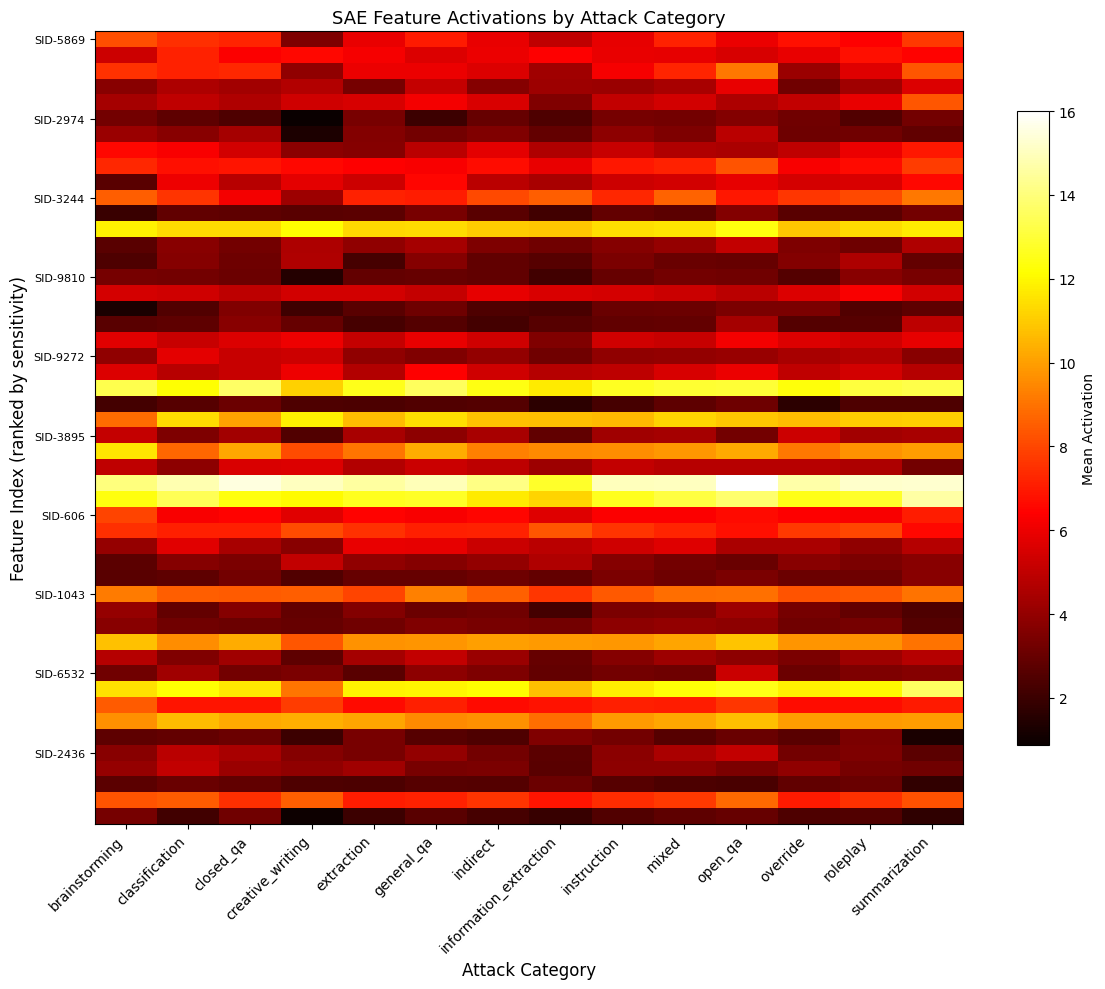

Saved to /content/drive/MyDrive/iris/results/figures/taxonomy_heatmap.png


In [7]:
heatmap_data, heatmap_cats, heatmap_feat_idx = build_taxonomy_heatmap_data(
    feature_matrix, categories, sensitivity, top_k=50
)

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(heatmap_data, cmap='hot', aspect='auto', interpolation='nearest')
ax.set_xlabel('Attack Category', fontsize=12)
ax.set_ylabel('Feature Index (ranked by sensitivity)', fontsize=12)
ax.set_title('SAE Feature Activations by Attack Category', fontsize=13)

ax.set_xticks(range(len(heatmap_cats)))
ax.set_xticklabels(heatmap_cats, rotation=45, ha='right', fontsize=10)

# Show every 5th feature index on y-axis
ytick_positions = range(0, len(heatmap_feat_idx), 5)
ax.set_yticks(list(ytick_positions))
ax.set_yticklabels([f'SID-{heatmap_feat_idx[i]}' for i in ytick_positions], fontsize=8)

plt.colorbar(im, ax=ax, label='Mean Activation', shrink=0.8)
plt.tight_layout()
save_path = DRIVE_ROOT / 'results' / 'figures' / 'taxonomy_heatmap.png'
fig.savefig(str(save_path), dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved to {save_path}')

## Step 4: Category-Specific Features

One-vs-rest analysis: which features are uniquely important for each category?

In [8]:
specific_features = identify_category_specific_features(
    feature_matrix, categories, top_k=10
)

print('Category-Specific Features (one-vs-rest):')
print('=' * 60)
for cat, features in specific_features.items():
    if features:
        print(f'\n{cat}:')
        for feat_idx, specificity in features[:5]:
            sens = sensitivity[feat_idx]
            direction = 'injection' if sens > 0 else 'normal'
            print(f'  SID-{feat_idx}: specificity={specificity:.4f}, sensitivity={sens:.4f} ({direction})')
    else:
        print(f'\n{cat}: no specific features found')

Category-Specific Features (one-vs-rest):

brainstorming:
  SID-4501: specificity=3.3846, sensitivity=-2.4044 (normal)
  SID-746: specificity=2.5076, sensitivity=0.4684 (injection)
  SID-7863: specificity=2.4815, sensitivity=-1.9979 (normal)
  SID-5387: specificity=2.4640, sensitivity=-1.1299 (normal)
  SID-4611: specificity=2.3836, sensitivity=-0.7053 (normal)

classification:
  SID-4180: specificity=2.2915, sensitivity=2.2042 (injection)
  SID-4124: specificity=2.2523, sensitivity=1.9733 (injection)
  SID-6231: specificity=2.2101, sensitivity=1.8050 (injection)
  SID-512: specificity=2.0613, sensitivity=-2.0728 (normal)
  SID-7313: specificity=1.9235, sensitivity=-0.8247 (normal)

closed_qa:
  SID-4340: specificity=2.3979, sensitivity=-1.0354 (normal)
  SID-1282: specificity=2.2984, sensitivity=1.7846 (injection)
  SID-561: specificity=2.0690, sensitivity=1.9383 (injection)
  SID-1261: specificity=2.0548, sensitivity=0.3264 (injection)
  SID-2483: specificity=1.9290, sensitivity=0.58

## Step 5: Attack Type Classification

Can we predict what *type* of attack it is from the feature pattern alone?

In [9]:
# Test classification on injection examples
inject_mask = labels == 1
inject_features = feature_matrix[inject_mask]
inject_categories = categories[inject_mask]

# Need to create fingerprints using only top-50 features for matching dimensions
abs_sens = np.abs(sensitivity)
top_50_idx = np.argsort(abs_sens)[::-1][:50]

correct = 0
total = 0
confusion = {}

for i in range(len(inject_features)):
    feat_subset = inject_features[i, top_50_idx]
    true_cat = inject_categories[i]
    pred_cat, confidence = classify_attack_type(feat_subset, fingerprints)

    if true_cat not in confusion:
        confusion[true_cat] = {}
    if pred_cat not in confusion[true_cat]:
        confusion[true_cat][pred_cat] = 0
    confusion[true_cat][pred_cat] += 1

    if pred_cat == true_cat:
        correct += 1
    total += 1

print(f'Attack type classification accuracy: {correct}/{total} ({correct/max(total,1):.1%})')
print()
print('Confusion breakdown:')
for true_cat in sorted(confusion.keys()):
    preds = confusion[true_cat]
    total_cat = sum(preds.values())
    print(f'  {true_cat} ({total_cat} examples):')
    for pred_cat, count in sorted(preds.items(), key=lambda x: -x[1]):
        print(f'    -> {pred_cat}: {count} ({count/total_cat:.0%})')

Attack type classification accuracy: 29/500 (5.8%)

Confusion breakdown:
  extraction (74 examples):
    -> information_extraction: 17 (23%)
    -> summarization: 13 (18%)
    -> creative_writing: 10 (14%)
    -> open_qa: 9 (12%)
    -> brainstorming: 7 (9%)
    -> extraction: 6 (8%)
    -> override: 4 (5%)
    -> general_qa: 2 (3%)
    -> mixed: 2 (3%)
    -> classification: 2 (3%)
    -> closed_qa: 1 (1%)
    -> roleplay: 1 (1%)
  indirect (74 examples):
    -> information_extraction: 17 (23%)
    -> summarization: 13 (18%)
    -> brainstorming: 10 (14%)
    -> open_qa: 9 (12%)
    -> creative_writing: 8 (11%)
    -> extraction: 5 (7%)
    -> classification: 3 (4%)
    -> roleplay: 3 (4%)
    -> mixed: 2 (3%)
    -> general_qa: 2 (3%)
    -> override: 2 (3%)
  mixed (203 examples):
    -> open_qa: 37 (18%)
    -> creative_writing: 29 (14%)
    -> brainstorming: 27 (13%)
    -> summarization: 25 (12%)
    -> information_extraction: 24 (12%)
    -> extraction: 16 (8%)
    -> mixed: 11 

## Step 6: Save Results

In [10]:
taxonomy_results = {
    'experiment': 'attack_taxonomy',
    'n_categories': len(fingerprints),
    'categories': list(fingerprints.keys()),
    'similarity_matrix': sim_matrix.tolist(),
    'category_names': cat_names,
    'classification_accuracy': correct / max(total, 1),
    'specific_features': {
        cat: [(int(idx), float(spec)) for idx, spec in feats[:5]]
        for cat, feats in specific_features.items()
    },
}

results_path = DRIVE_ROOT / 'results' / 'metrics' / 'attack_taxonomy.json'
results_path.parent.mkdir(parents=True, exist_ok=True)
results_path.write_text(json.dumps(taxonomy_results, indent=2))
print(f'Results saved to {results_path}')

print()
print('=' * 60)
print('  Attack Taxonomy \u2014 Key Findings')
print('=' * 60)
print()
print('The SAE features encode structured representations of attack types.')
print('Different injection strategies activate distinct feature subsets,')
print('demonstrating the SAE learned more than just binary classification.')
print()
print('This has implications for:')
print('  1. Targeted defenses per attack category')
print('  2. Understanding why certain attacks evade detection')
print('  3. Feature steering calibrated by attack type')

Results saved to /content/drive/MyDrive/iris/results/metrics/attack_taxonomy.json

  Attack Taxonomy — Key Findings

The SAE features encode structured representations of attack types.
Different injection strategies activate distinct feature subsets,
demonstrating the SAE learned more than just binary classification.

This has implications for:
  1. Targeted defenses per attack category
  2. Understanding why certain attacks evade detection
  3. Feature steering calibrated by attack type
